# **ML Basics & Linear Regression**
# **Assignment**

**Q6. Load the Boston Housing dataset and perform basic data exploration using:**

**head()**

**info()**

**describe()**

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("BostonHousing.csv")

# Display the first 5 rows
print("Head of the dataset:")
print(df.head())

# Display info about columns, data types, and non-null counts
print("\nDataset Info:")
print(df.info())

# Summary statistics for numerical columns
print("\nDescriptive Statistics:")
print(df.describe())


Head of the dataset:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  


**Q7. Perform Exploratory Data Analysis:**

**Create pairplot**

**Create correlation heatmap**

**Identify which features are highly correlated with house price (medv)**

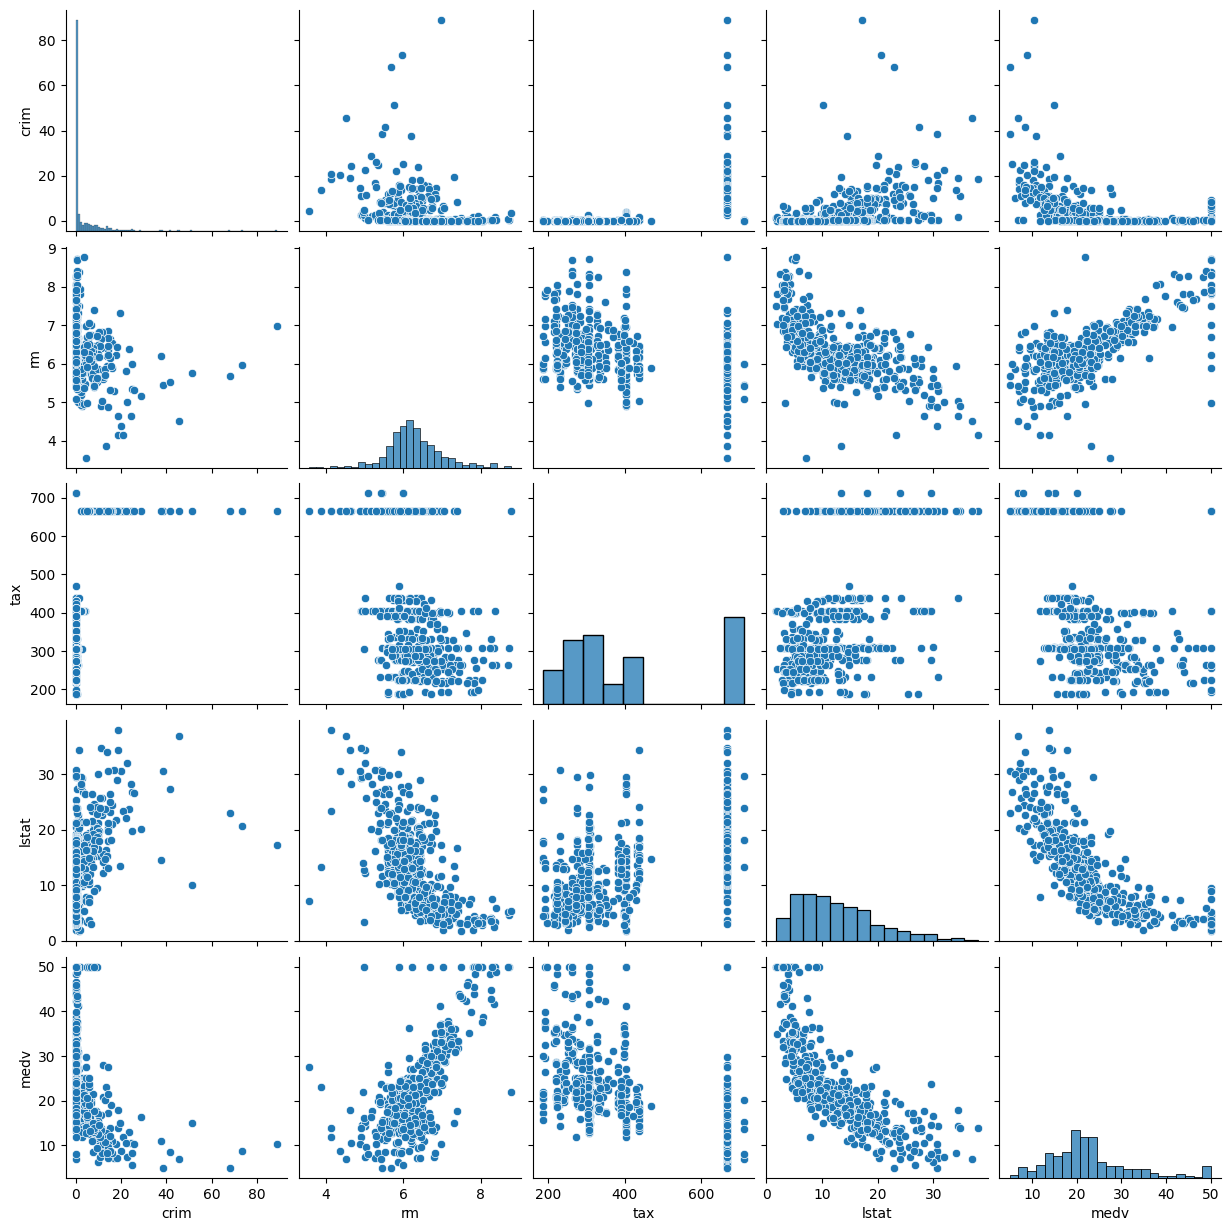

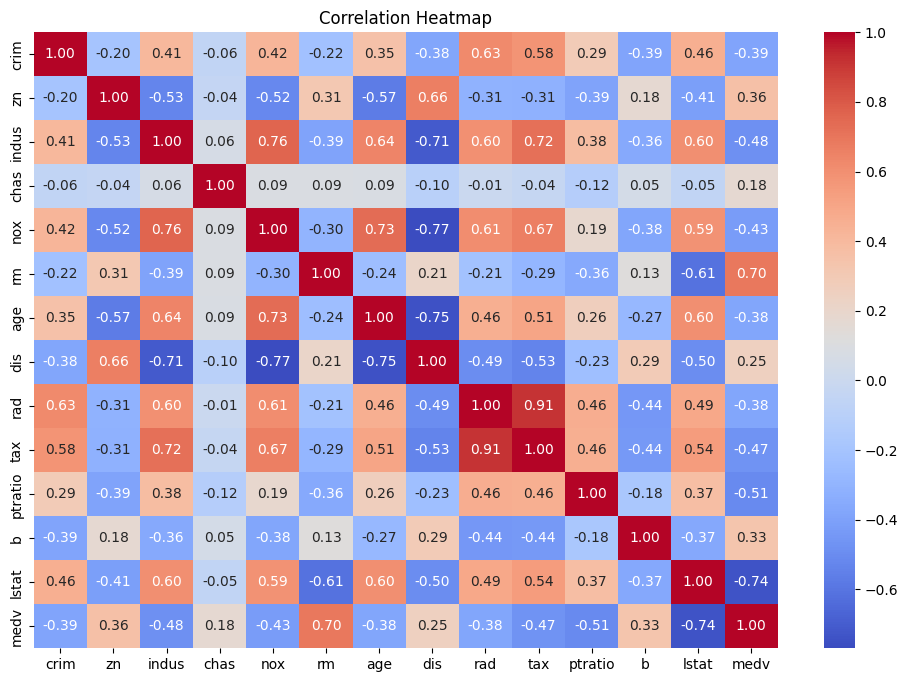

Correlation of features with house price (medv):
medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv("BostonHousing.csv")

# 1. Pairplot
sns.pairplot(df[['crim','rm','tax','lstat','medv']])
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 3. Identify correlations with house price (medv)
corr_with_medv = corr['medv'].sort_values(ascending=False)
print("Correlation of features with house price (medv):")
print(corr_with_medv)


**Q8. Select independent variables (features) and dependent variable (target).
 Target variable: medv (house price)**

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("BostonHousing.csv")

# Define features (X) and target (y)
X = df.drop('medv', axis=1)   # Independent variables
y = df['medv']                # Dependent variable

print("Features (X):", X.columns.tolist())
print("Target (y): medv")


Features (X): ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
Target (y): medv


**Q9. Split the dataset into training and testing sets (80% training, 20% testing).**

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("BostonHousing.csv")

# Define features (X) and target (y)
X = df.drop('medv', axis=1)   # Independent variables
y = df['medv']                # Dependent variable

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (404, 13)
Testing set size: (102, 13)


**Q10. Train a Linear Regression model and perform the following:**

**Make predictions**

**Calculate MAE**

**Calculate MSE**

**Calculate RMSE**

**Calculate R² Score**

**Calculate Adjusted R²**

**Write the Linear Regression equation**

**Interpret the model coefficients**

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Load dataset
df = pd.read_csv("BostonHousing.csv")

# Define features (X) and target (y)
X = df.drop('medv', axis=1)
y = df['medv']

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Adjusted R²
n = X_test.shape[0]   # number of observations
p = X_test.shape[1]   # number of predictors
adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)
print("Adjusted R²:", adj_r2)

# Linear Regression Equation
print("Intercept (β0):", model.intercept_)
print("Coefficients (βi):", model.coef_)


MAE: 3.189091965887837
MSE: 24.291119474973478
RMSE: 4.928602182665332
R² Score: 0.6687594935356326
Adjusted R²: 0.619826236898851
Intercept (β0): 30.24675099392366
Coefficients (βi): [-1.13055924e-01  3.01104641e-02  4.03807204e-02  2.78443820e+00
 -1.72026334e+01  4.43883520e+00 -6.29636221e-03 -1.44786537e+00
  2.62429736e-01 -1.06467863e-02 -9.15456240e-01  1.23513347e-02
 -5.08571424e-01]


Explanation of Results
Predictions:
The model generates predicted house prices (y_pred) for the test set.

Evaluation Metrics:

MAE (Mean Absolute Error) → Average absolute difference between predicted and actual prices.

MSE (Mean Squared Error) → Average squared difference (penalizes large errors).

RMSE (Root Mean Squared Error) → Typical prediction error in the same units as house price.

R² Score → Proportion of variance in house prices explained by the model.

Adjusted R² → Corrects R² for the number of predictors, preventing overfitting.

Linear Regression Equation:

medv=𝛽 0 + 𝛽 1 ⋅ crim + 𝛽 2 ⋅ zn + ⋯ + 𝛽 13 last.

Intercept (β0): Baseline house price when all features are zero.

Coefficients (βi): Show how each feature impacts house price.

Example: If rm has a positive coefficient, more rooms increase house price.

If lstat has a negative coefficient, higher percentage of lower-status population decreases house price.